In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Panel A-B

In [3]:
klein = sc.read_h5ad('../datasets/Weinreb/klein_update.h5ad')
klein

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

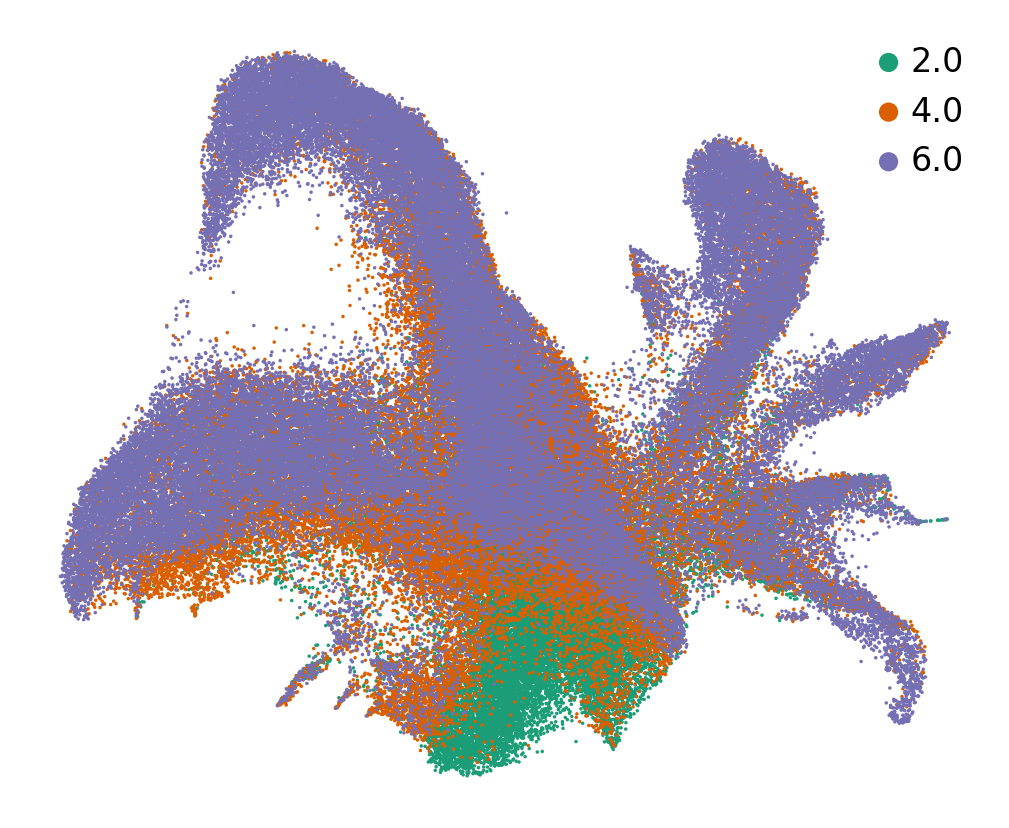

In [4]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.scatter(
    klein, basis='umap', color='Time_point', 
    legend_loc='best', palette=sns.color_palette('Dark2'), 
    size=10, frameon=False, title='',
    legend_fontsize=15)

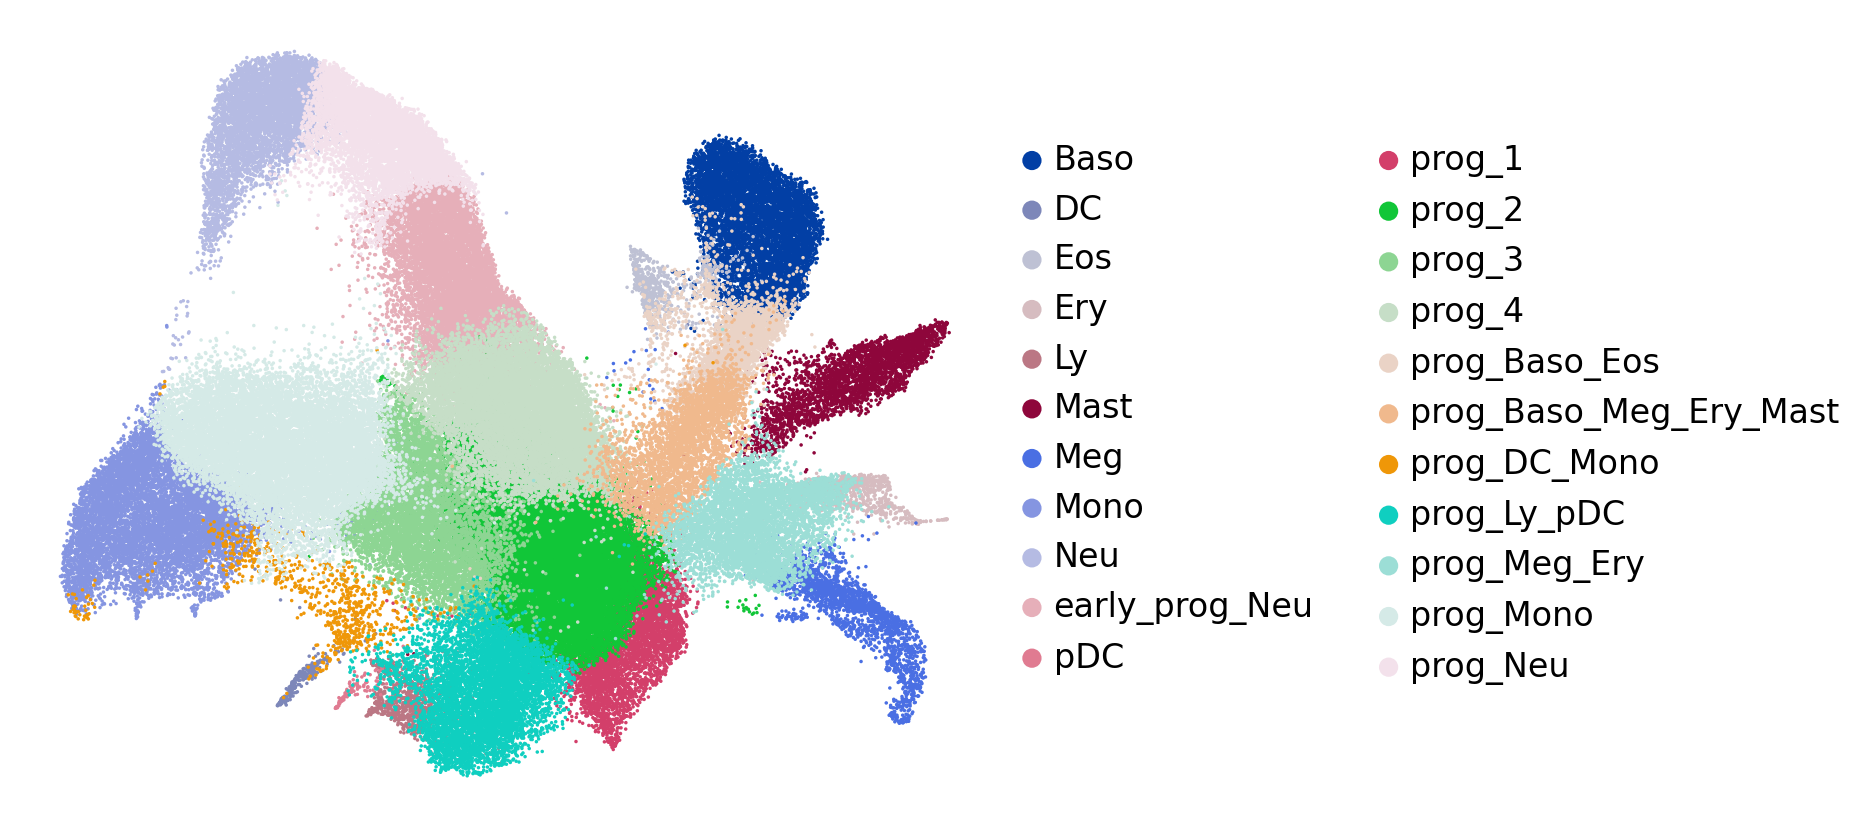

In [5]:
sc.pl.scatter(
    klein, basis='umap', color='label_man', 
    legend_loc='right margin', 
    size=10, frameon=False, 
    title='', legend_fontsize=15
)

In [6]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
klein.obs['group'] = pd.Categorical(klein.obs['Meta clones'], categories=group_labels)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


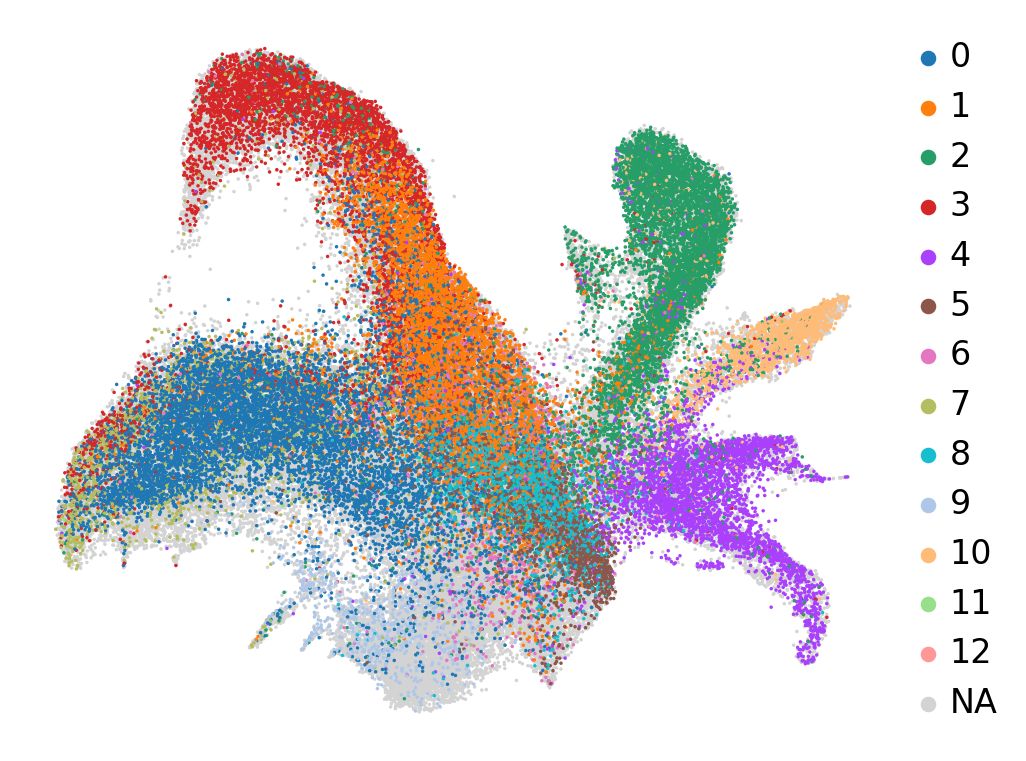

In [7]:
sc.pl.umap(
    klein, groups=group_labels, color=['group'],
    size=10, frameon=False, title='', legend_fontsize=15
)

### Panel C

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


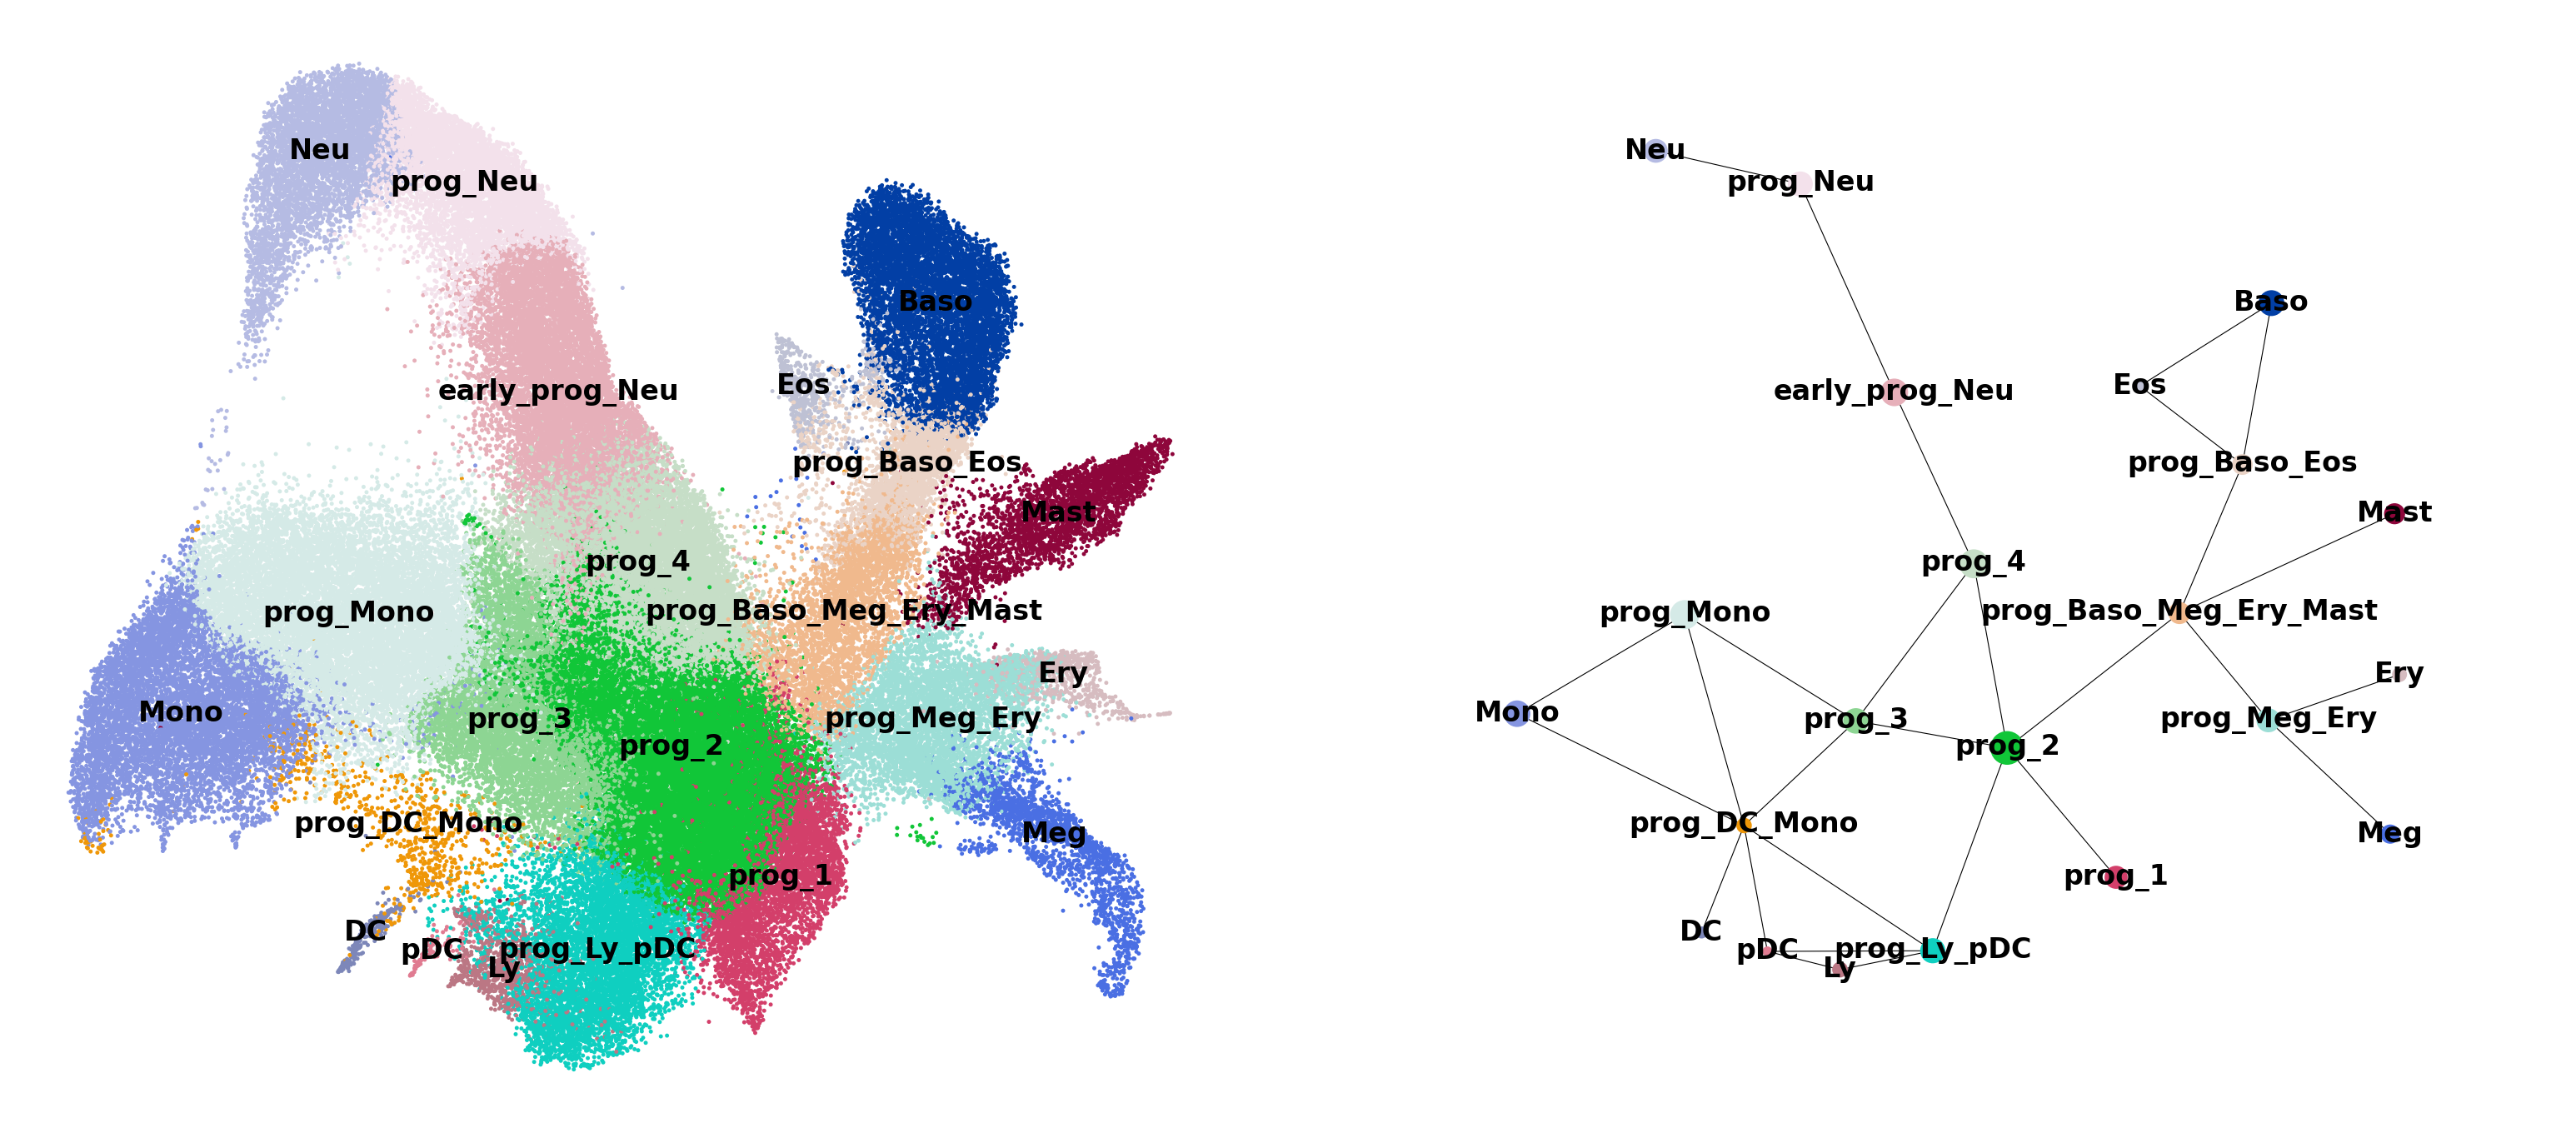

In [9]:
sc.set_figure_params(dpi_save=300, figsize=(10, 10), transparent=True)
sc.pl.paga_compare(
    klein, basis='umap', threshold=0.25,
    size=20, frameon=False, 
    title='', legend_fontsize=15, edge_width_scale=0.5, max_edge_width=0.5
)

### Panel D

In [10]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


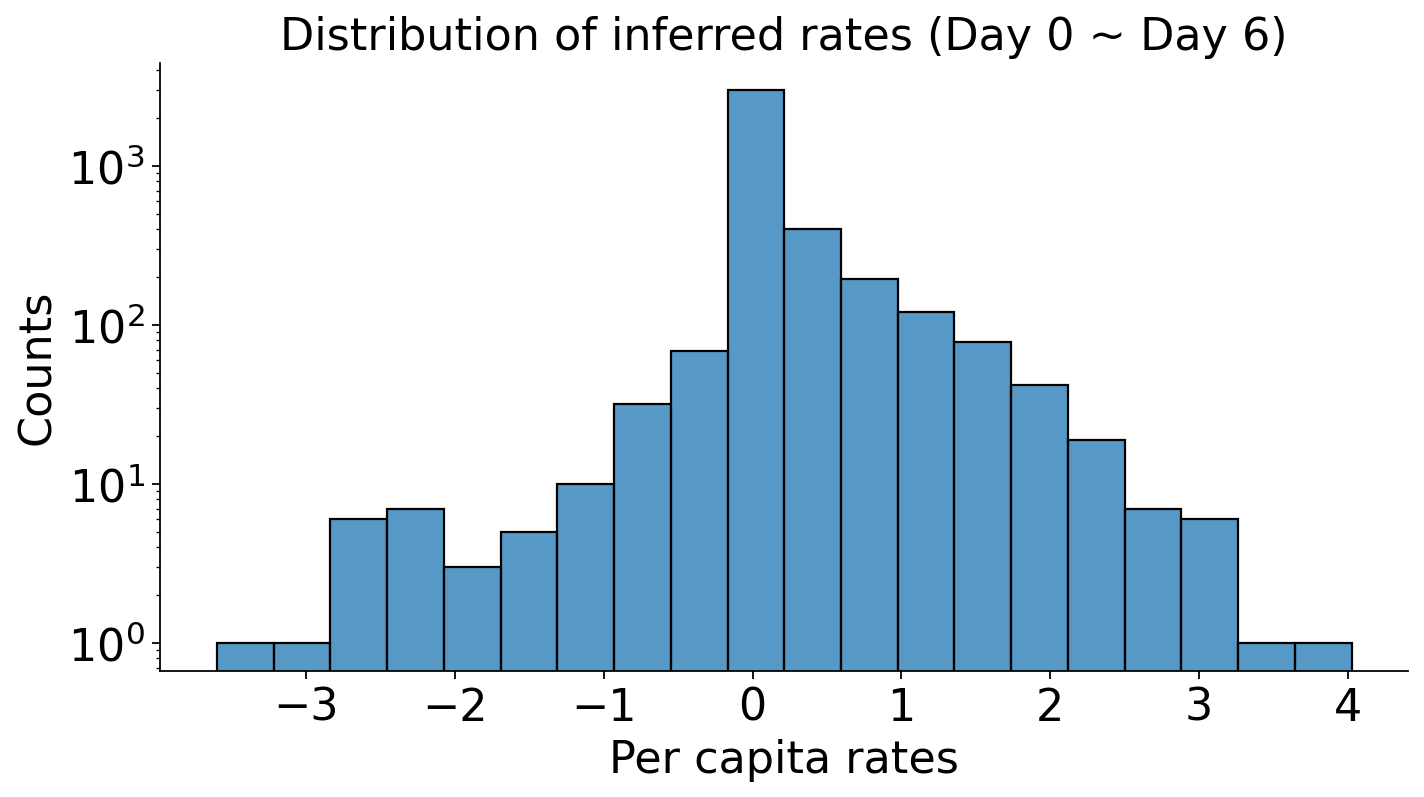

In [11]:
from clonaltrans.pl import rates_in_paga
rates_in_paga(model)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


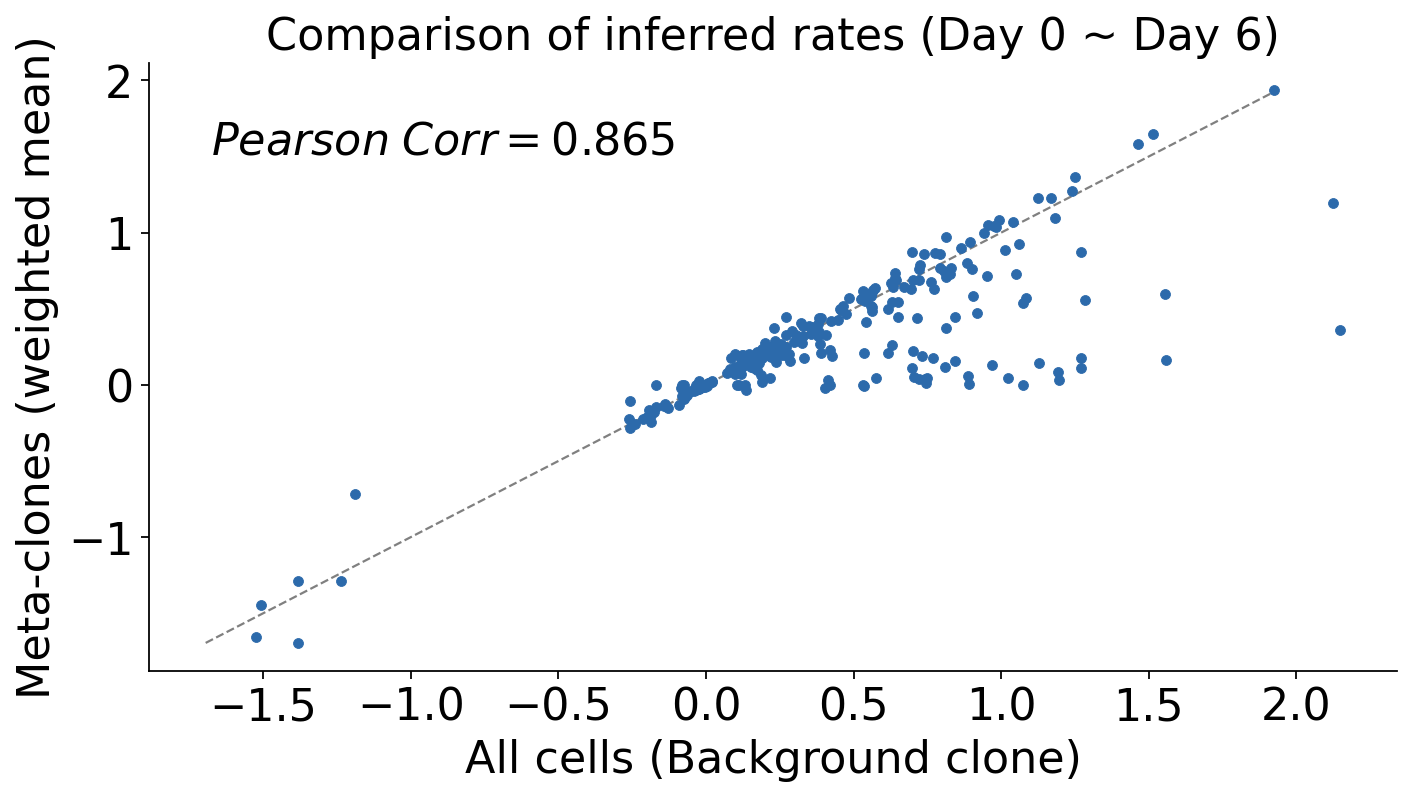

In [12]:
from clonaltrans.pl import compare_with_bg
compare_with_bg(model)

### Panel E

In [13]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/original/checkpoints/WeinrebDynamicRates/0301_112802/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [16]:
cluster_names = np.array([
    'prog_1', 'prog_2', 'prog_3', 'prog_4', 
    'prog_Baso_Meg_Ery_Mast',
    'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
    'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Eos',
    'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'pDC'])

In [17]:
gillespie_dir='./trials/original/checkpoints/WeinrebDynamicGillespie/0301_211649/models/'
gillespie_dir_valid = os.path.join(gillespie_dir, 'clone_1')

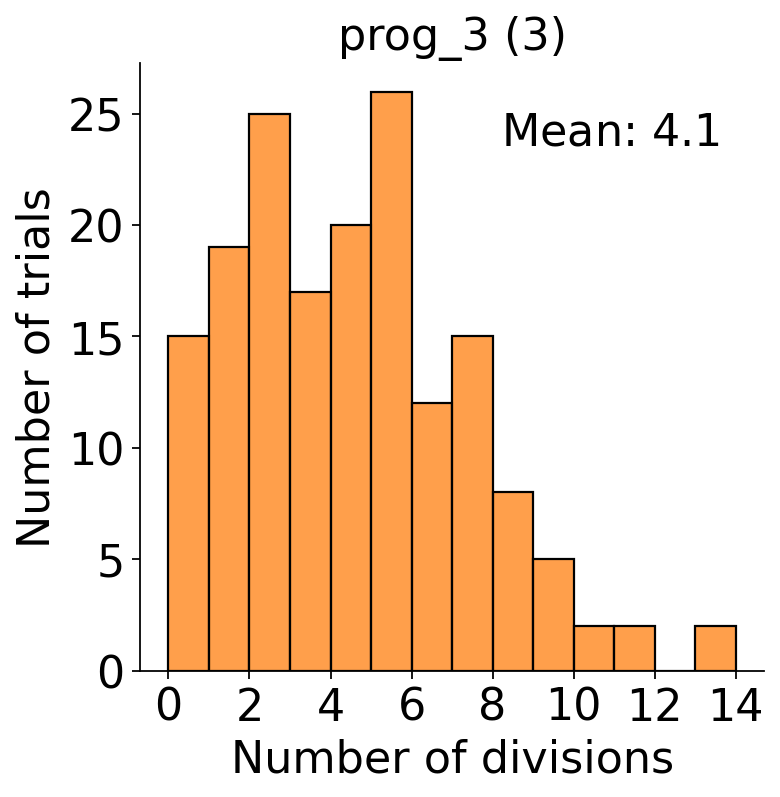

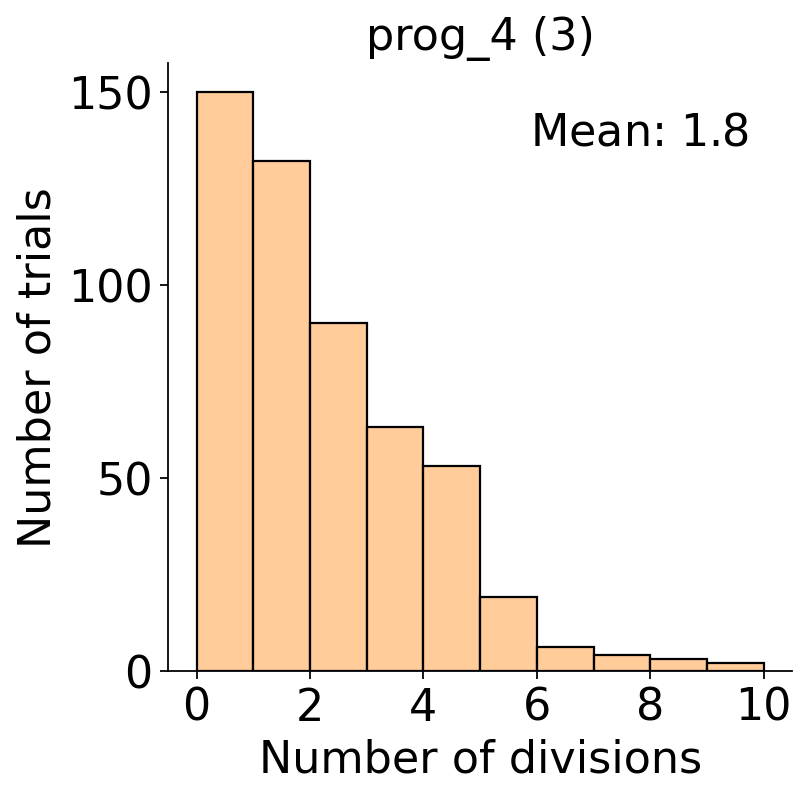

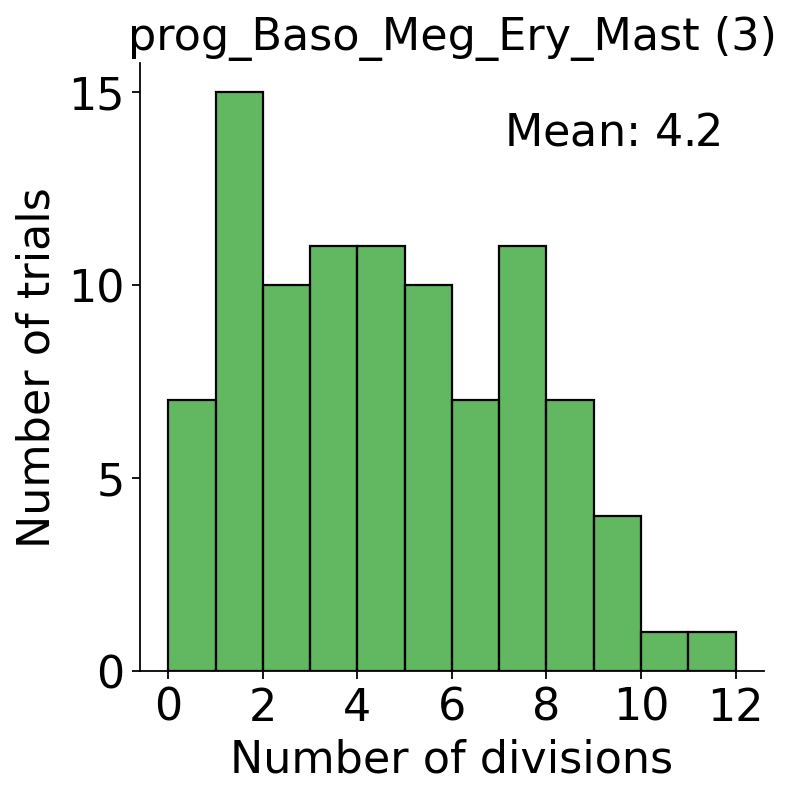

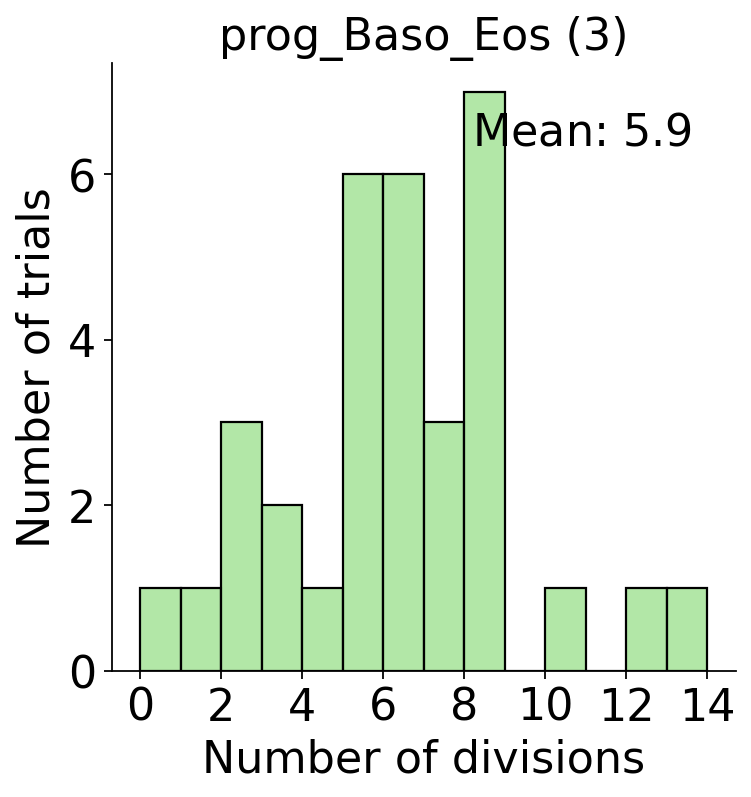

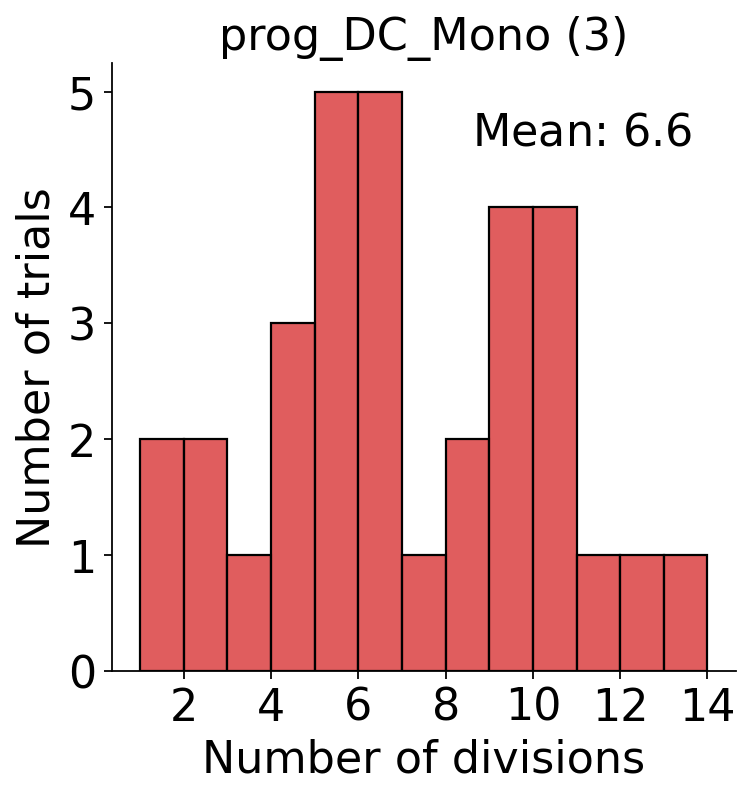

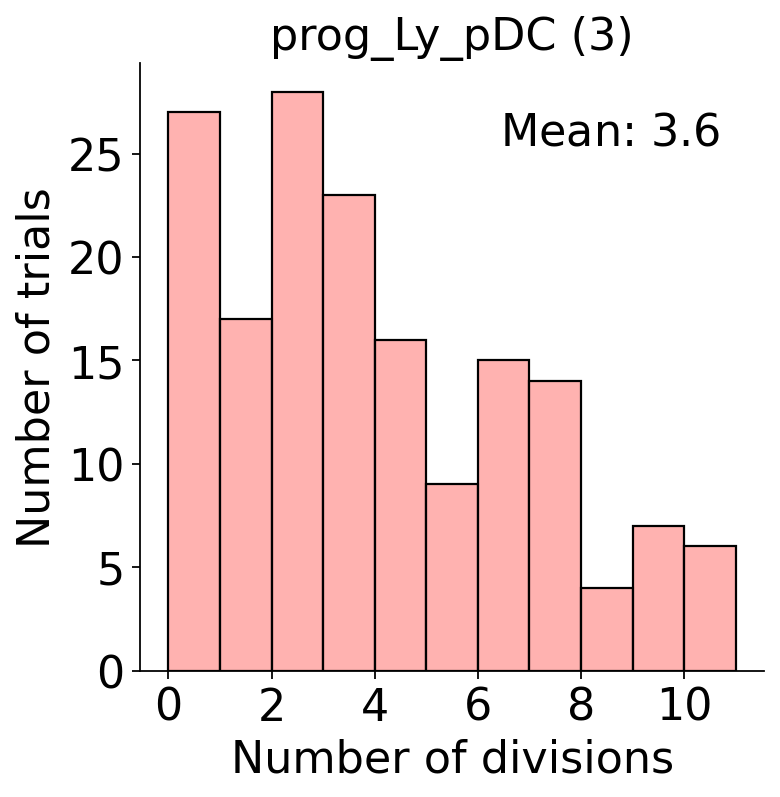

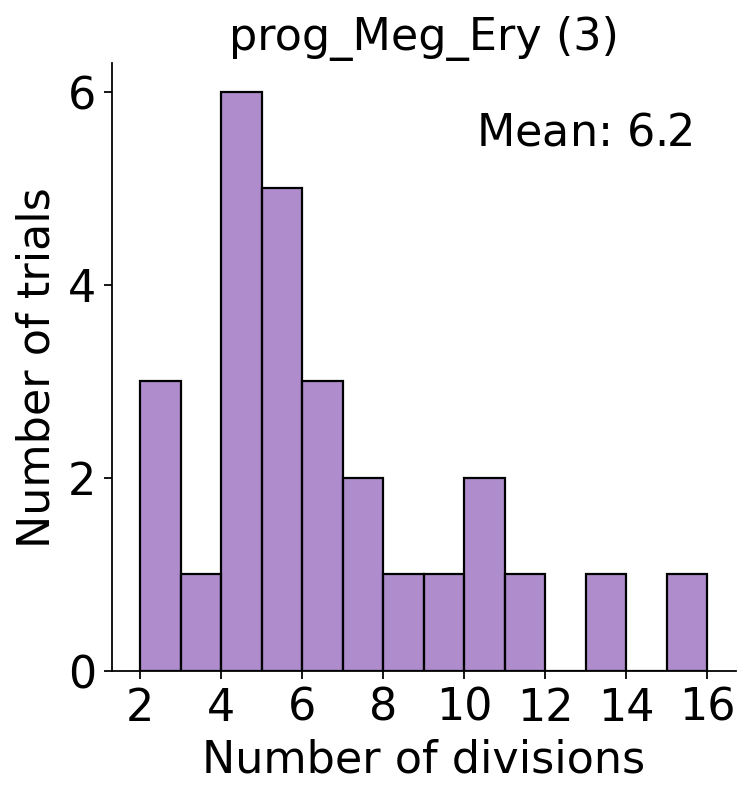

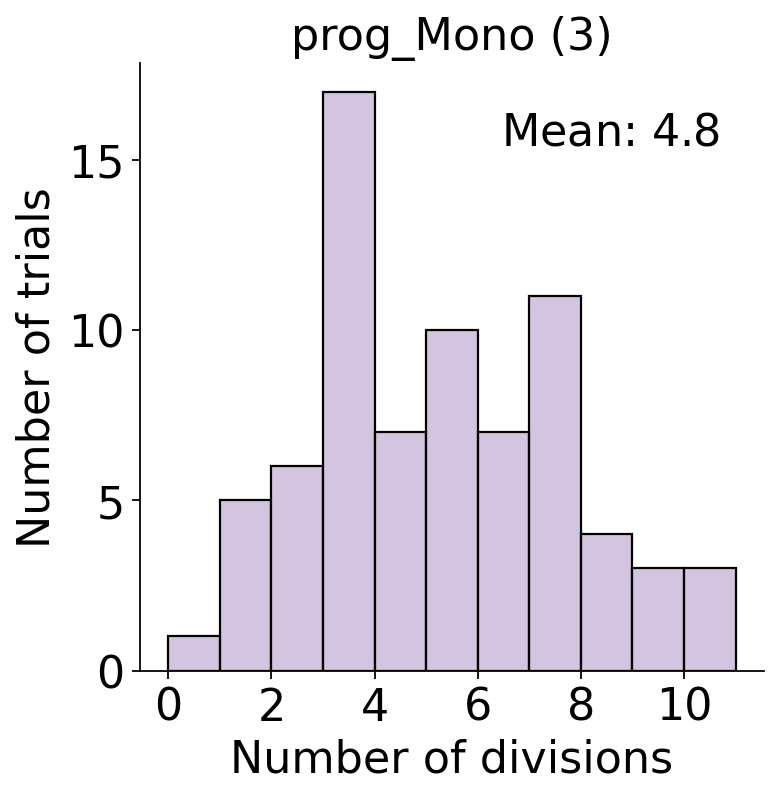

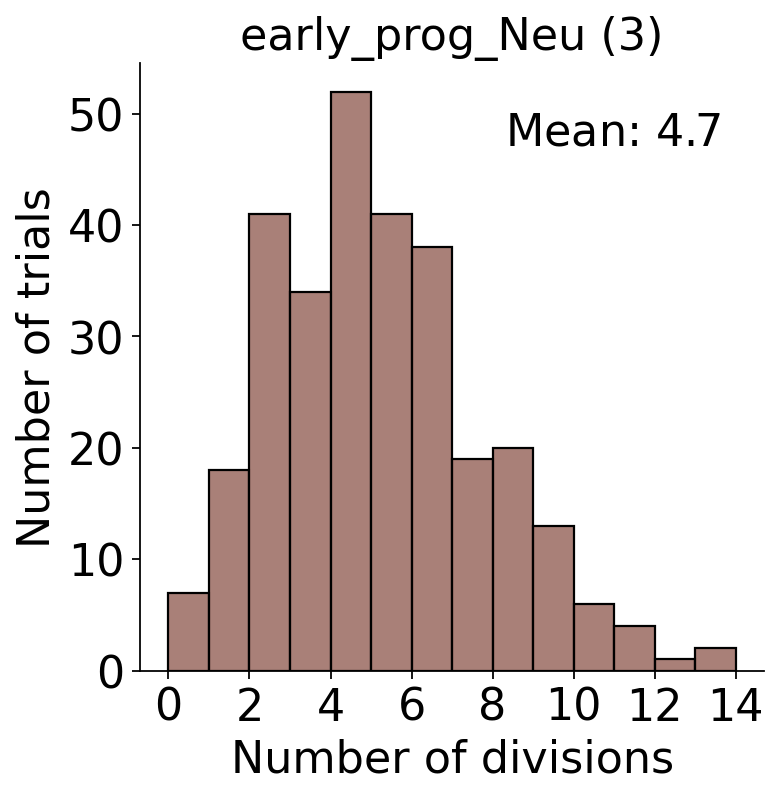

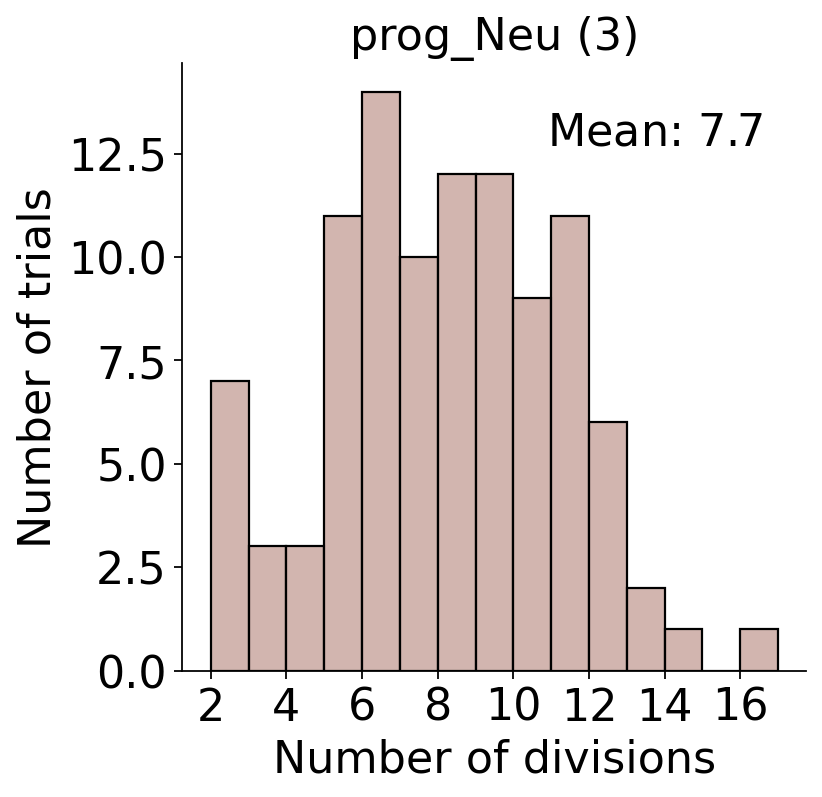

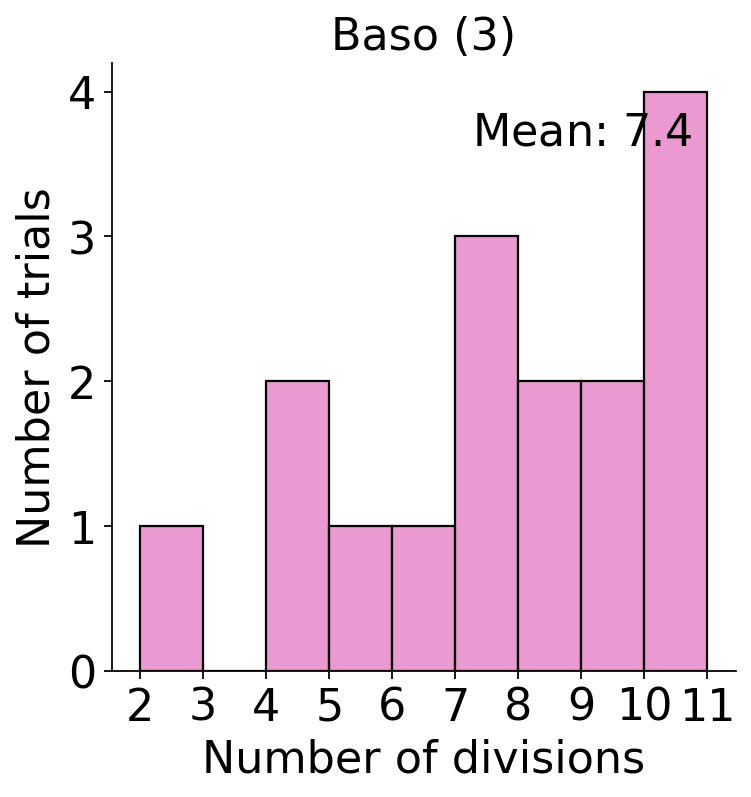

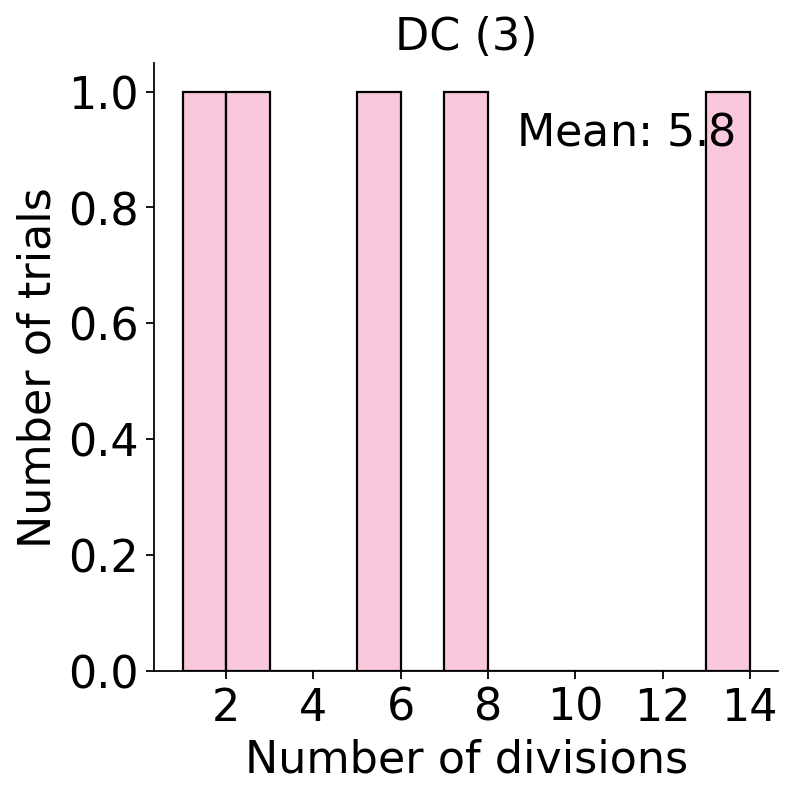

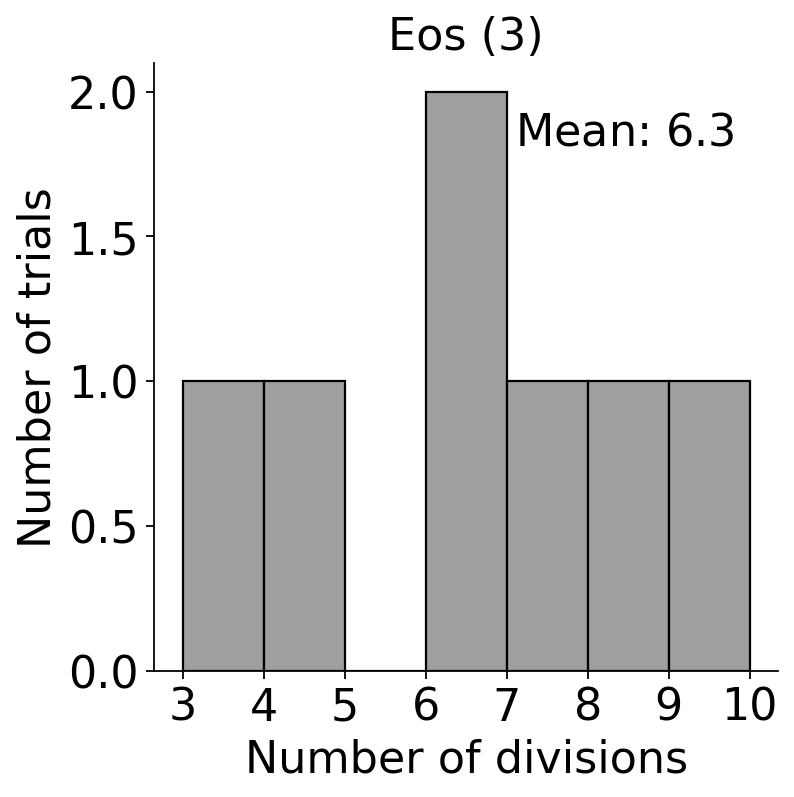

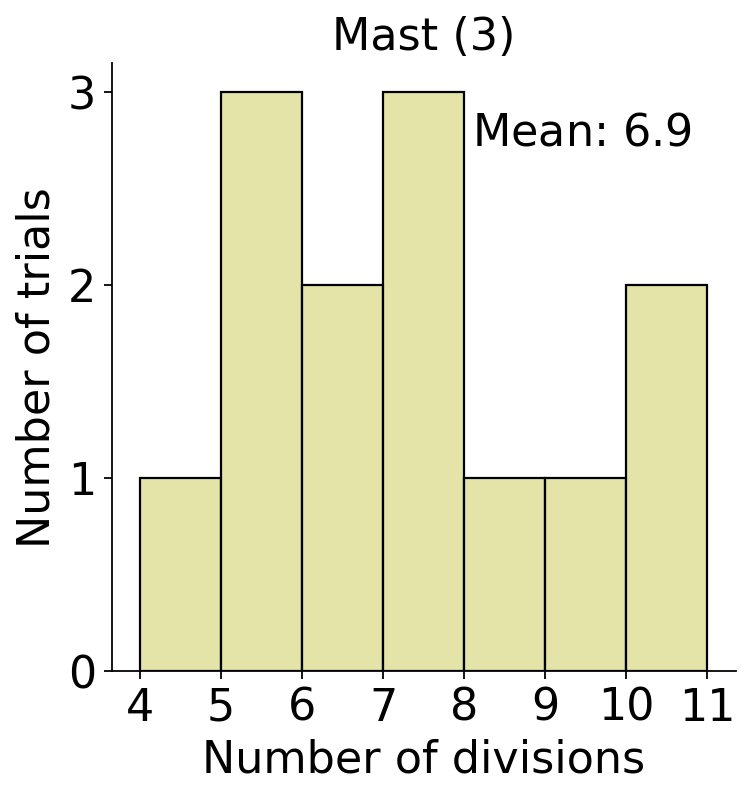

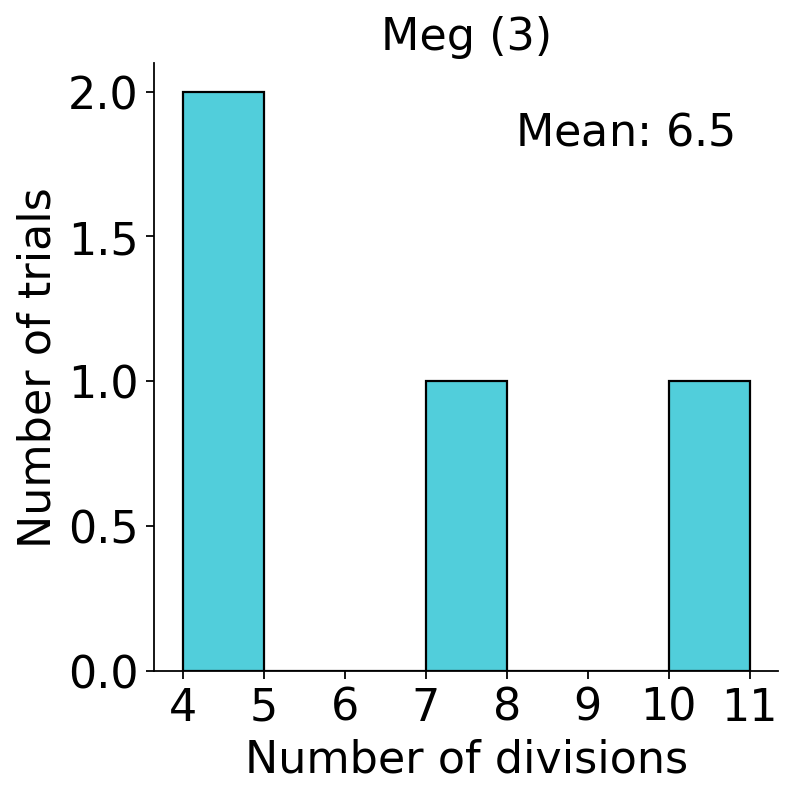

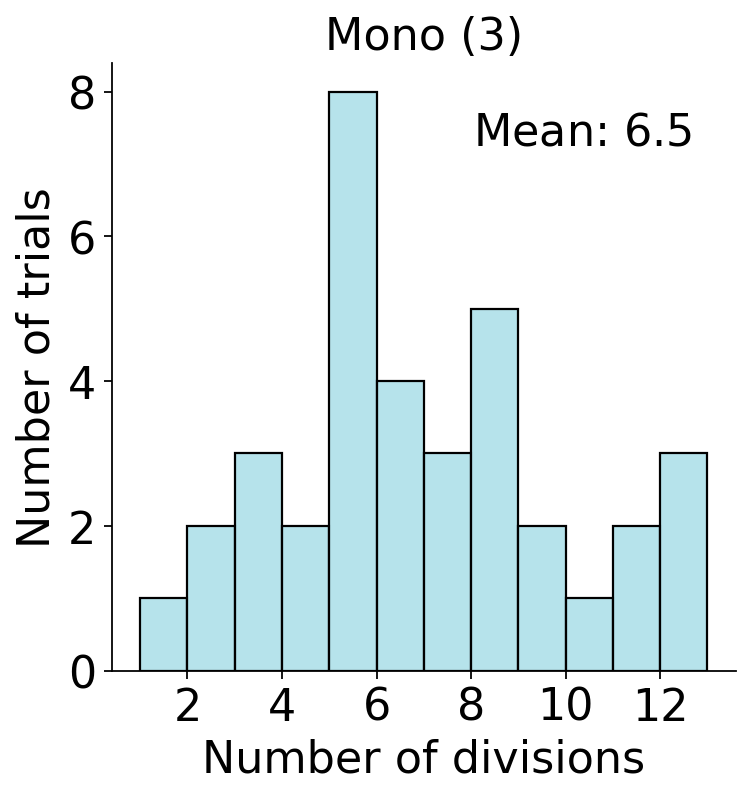

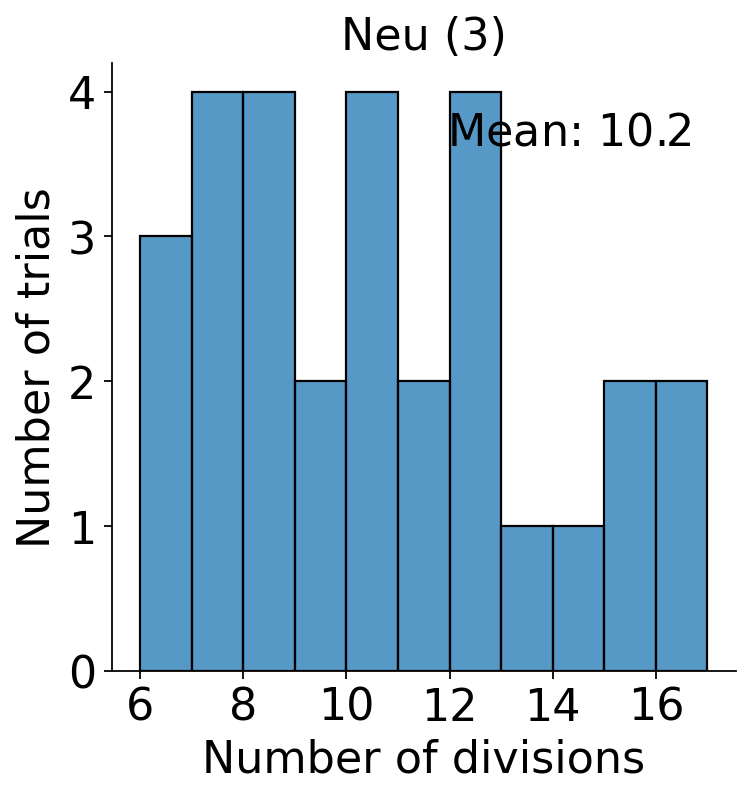

In [21]:
from clonaltrans.pl import visualize_num_div
visualize_num_div(cluster_names, gillespie_dir=gillespie_dir_valid, clone_name=3)

### Panel F

In [22]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []
length, mean, num_trails = [], [], []

for clone in range(model.N.shape[1]):
    distribution, counts = get_div_distribution(os.path.join(gillespie_dir, f'clone_{clone}'), cluster_names)
    distributions.append(distribution)
    num_trails.append(counts)

In [23]:
length = copy.deepcopy(distributions)
mean = copy.deepcopy(distributions)

for clone in mean:
    for key in clone.keys():
        clone[key] = np.mean(clone[key]) if len(clone[key]) > 0 else 0

for clone in length:
    for key in clone.keys():
        clone[key] = len(clone[key])

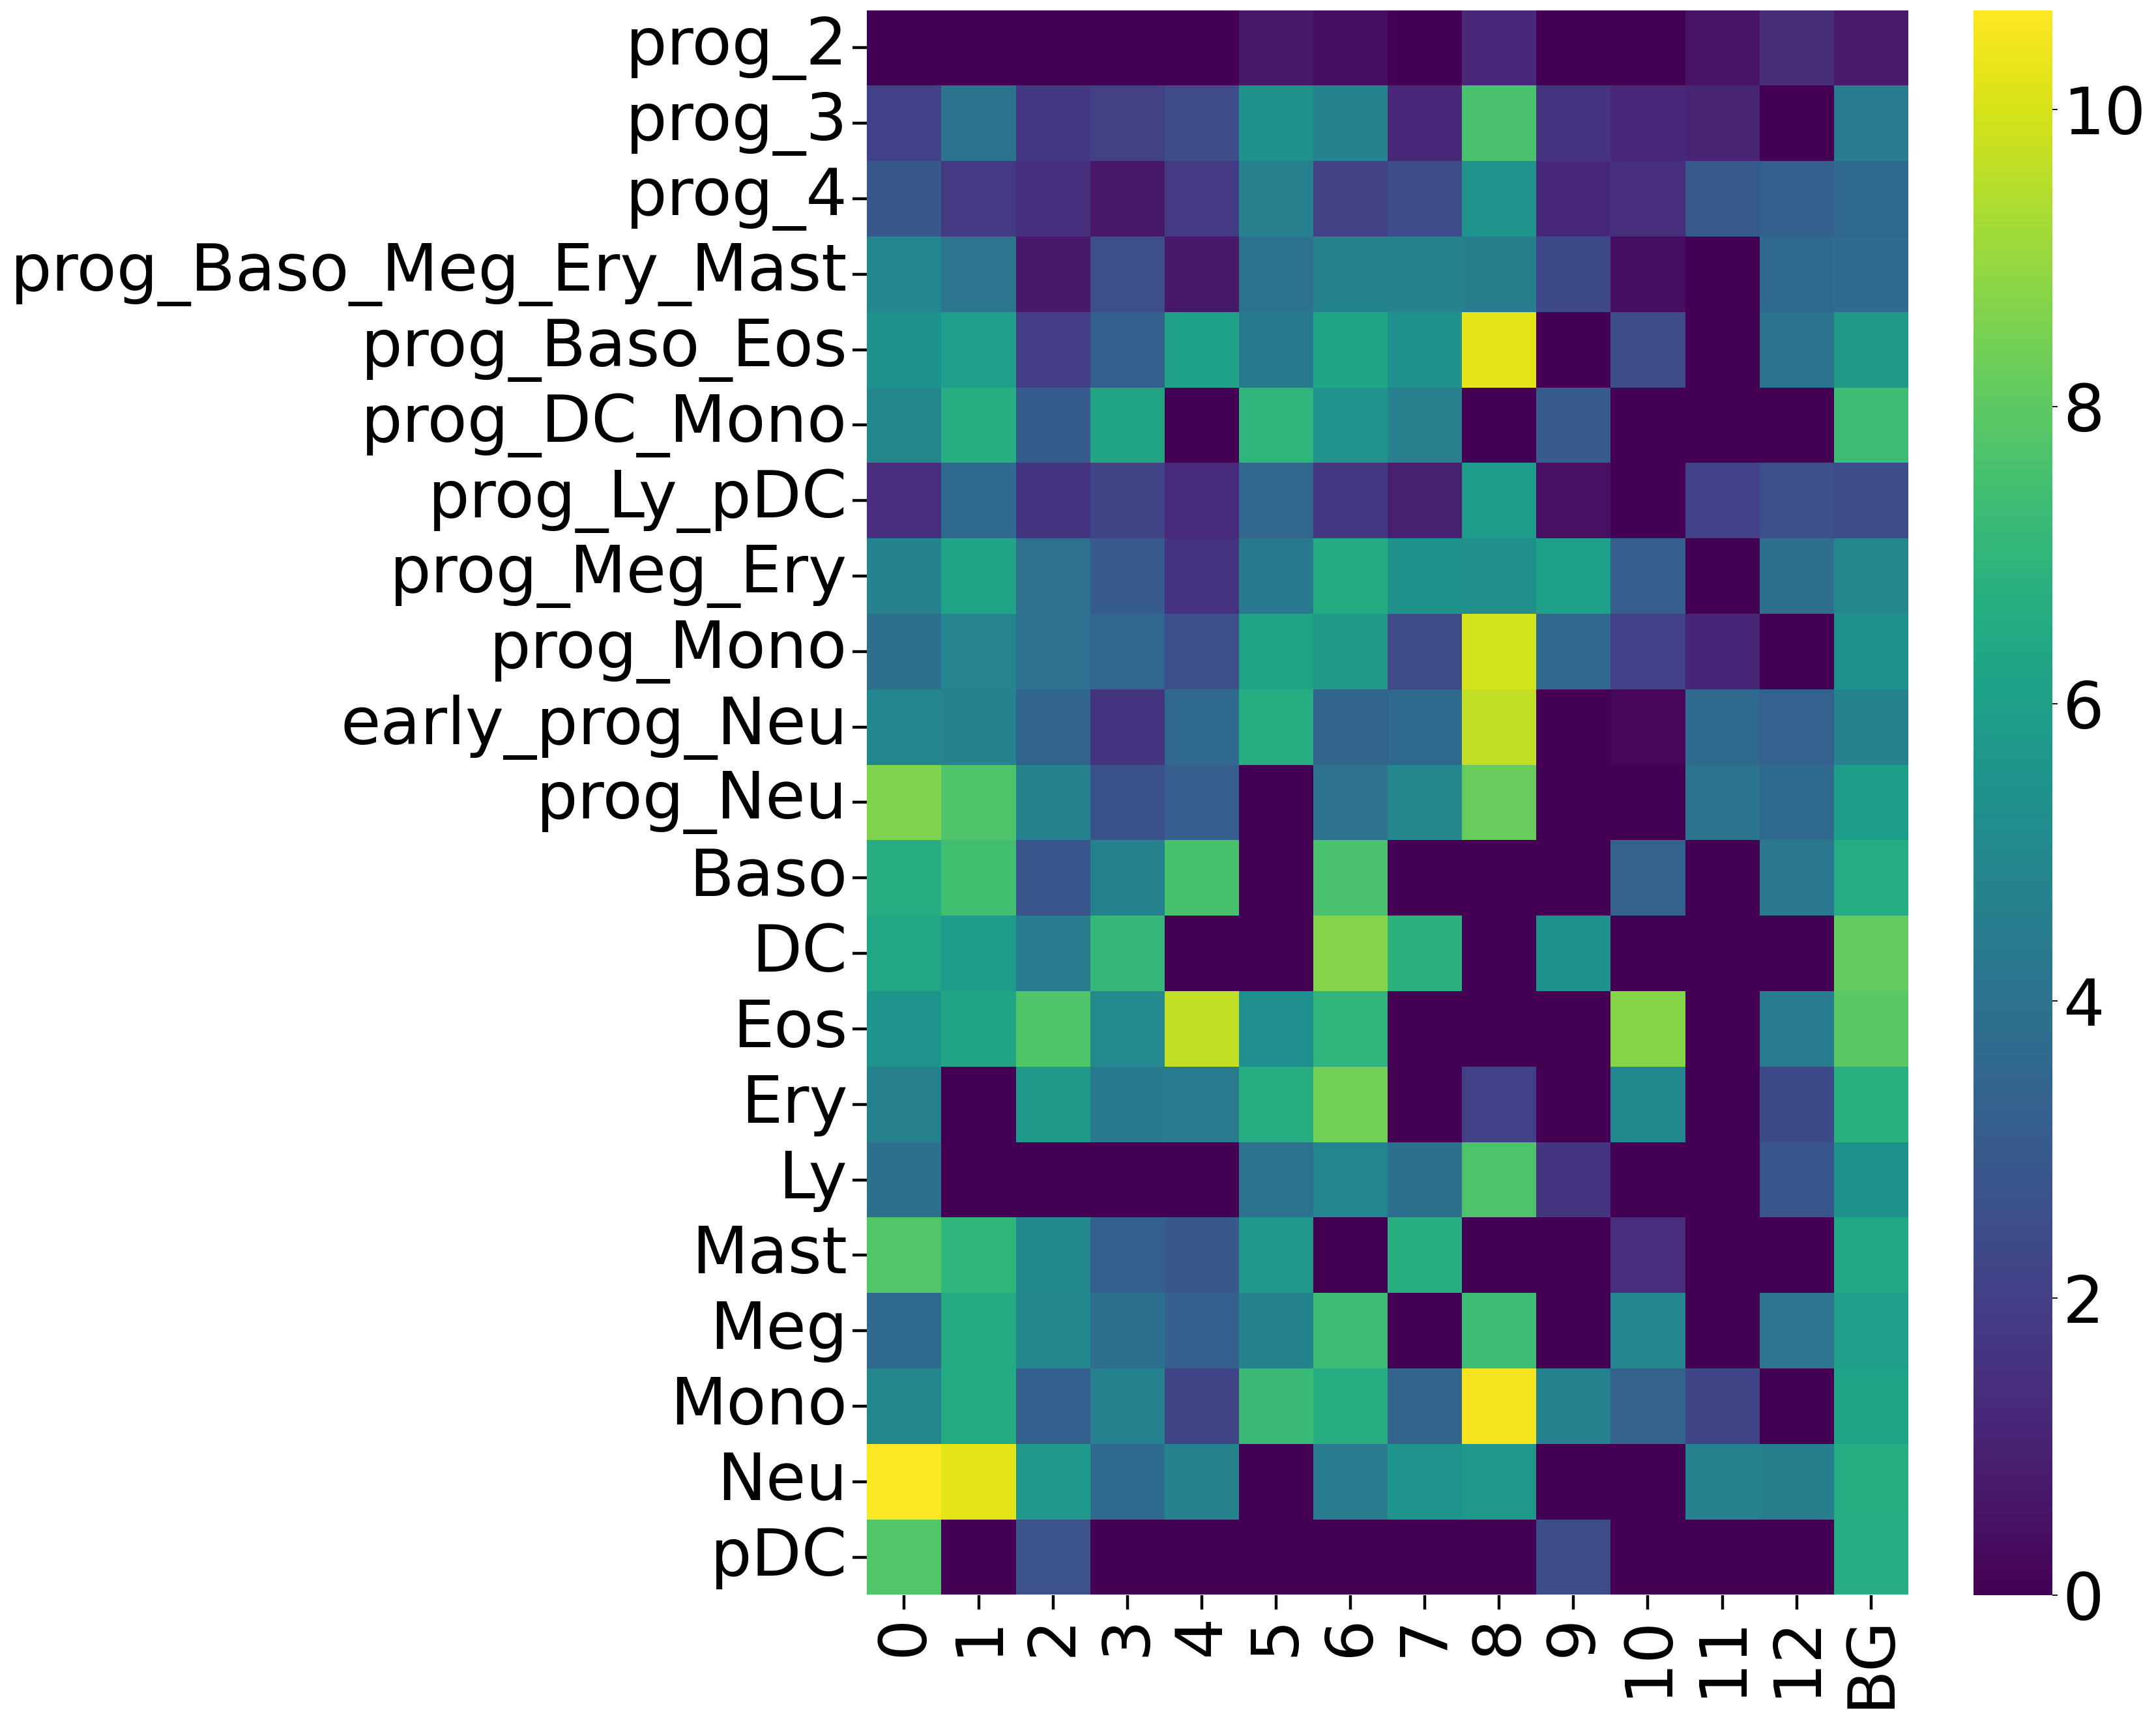

In [25]:
from clonaltrans.pl import mean_division_to_first
mean_division_to_first(mean)

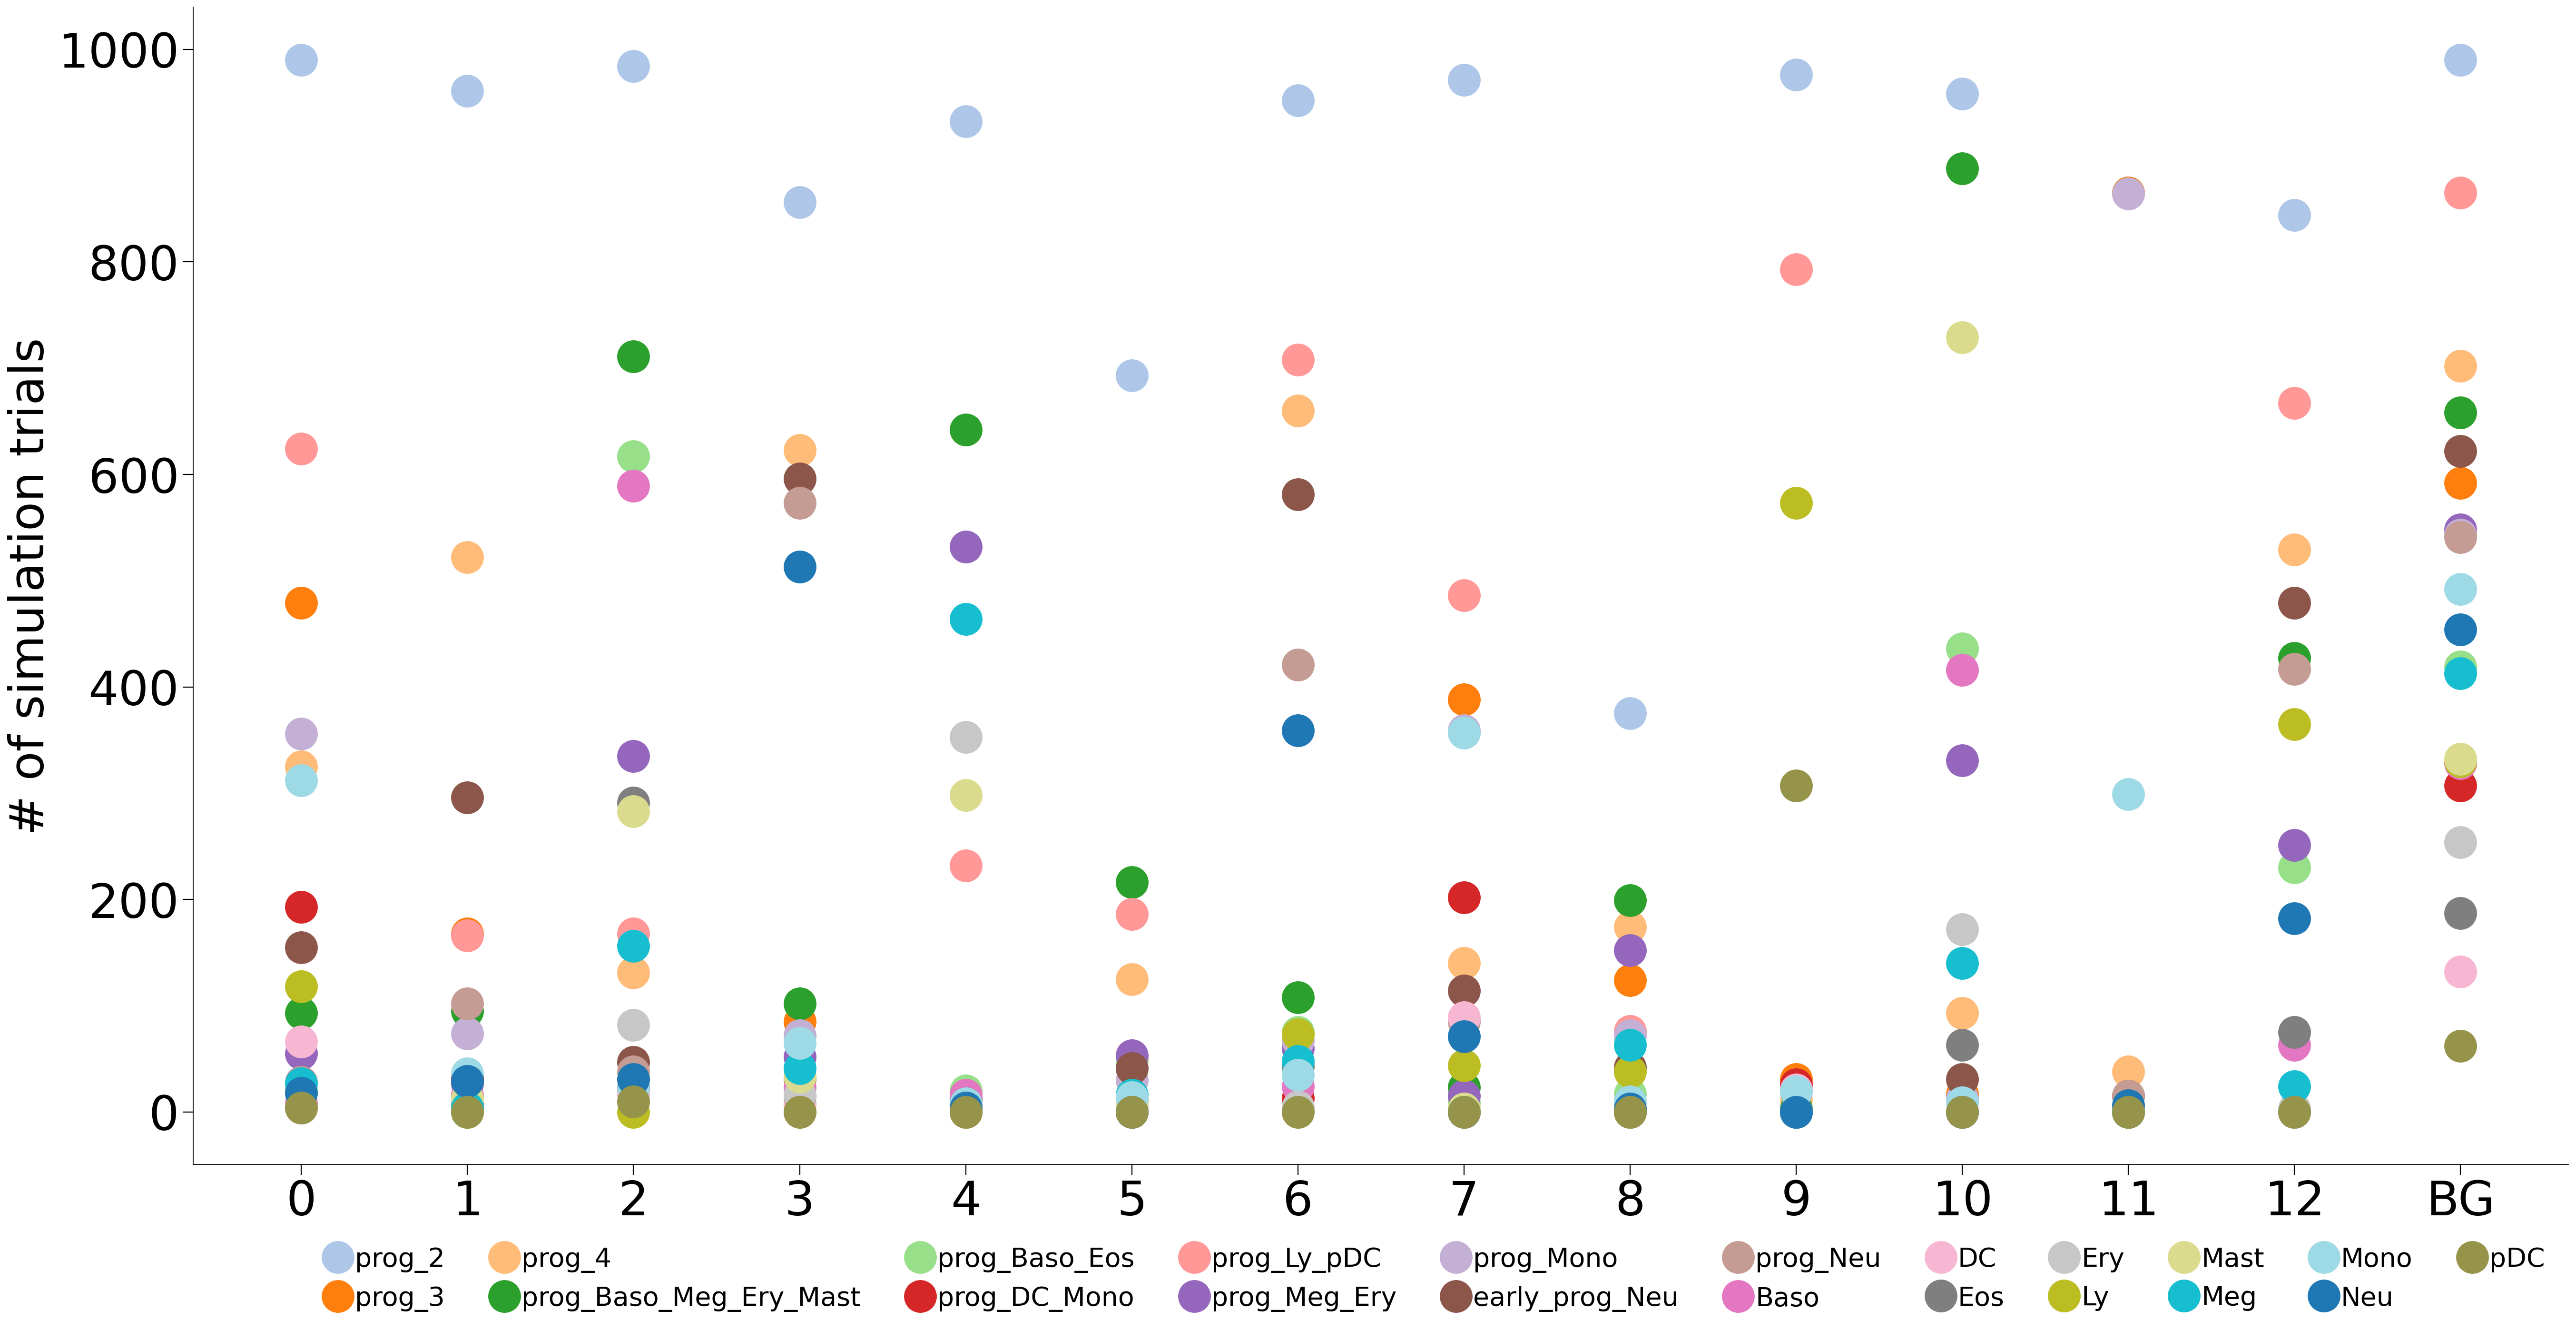

In [28]:
from clonaltrans.pl import succeed_trails_to_first
succeed_trails_to_first(length, num_trails)